In [6]:
# !pip install nba_api

Attempting to fetch real NBA data...
Successfully fetched 10 players from NBA API
Sample data:
               PLAYER_NAME   PTS   REB  AST  STL  BLK  TOV  FG_PCT  FT_PCT
0              Joel Embiid  34.7  11.0  5.6  1.2  1.7  3.8   0.529   0.883
1              Luka Dončić  33.9   9.2  9.8  1.4  0.5  4.0   0.487   0.786
2    Giannis Antetokounmpo  30.4  11.5  6.5  1.2  1.1  3.4   0.611   0.657
3  Shai Gilgeous-Alexander  30.1   5.5  6.2  2.0  0.9  2.2   0.535   0.874
4            Jalen Brunson  28.7   3.6  6.7  0.9  0.2  2.4   0.479   0.847


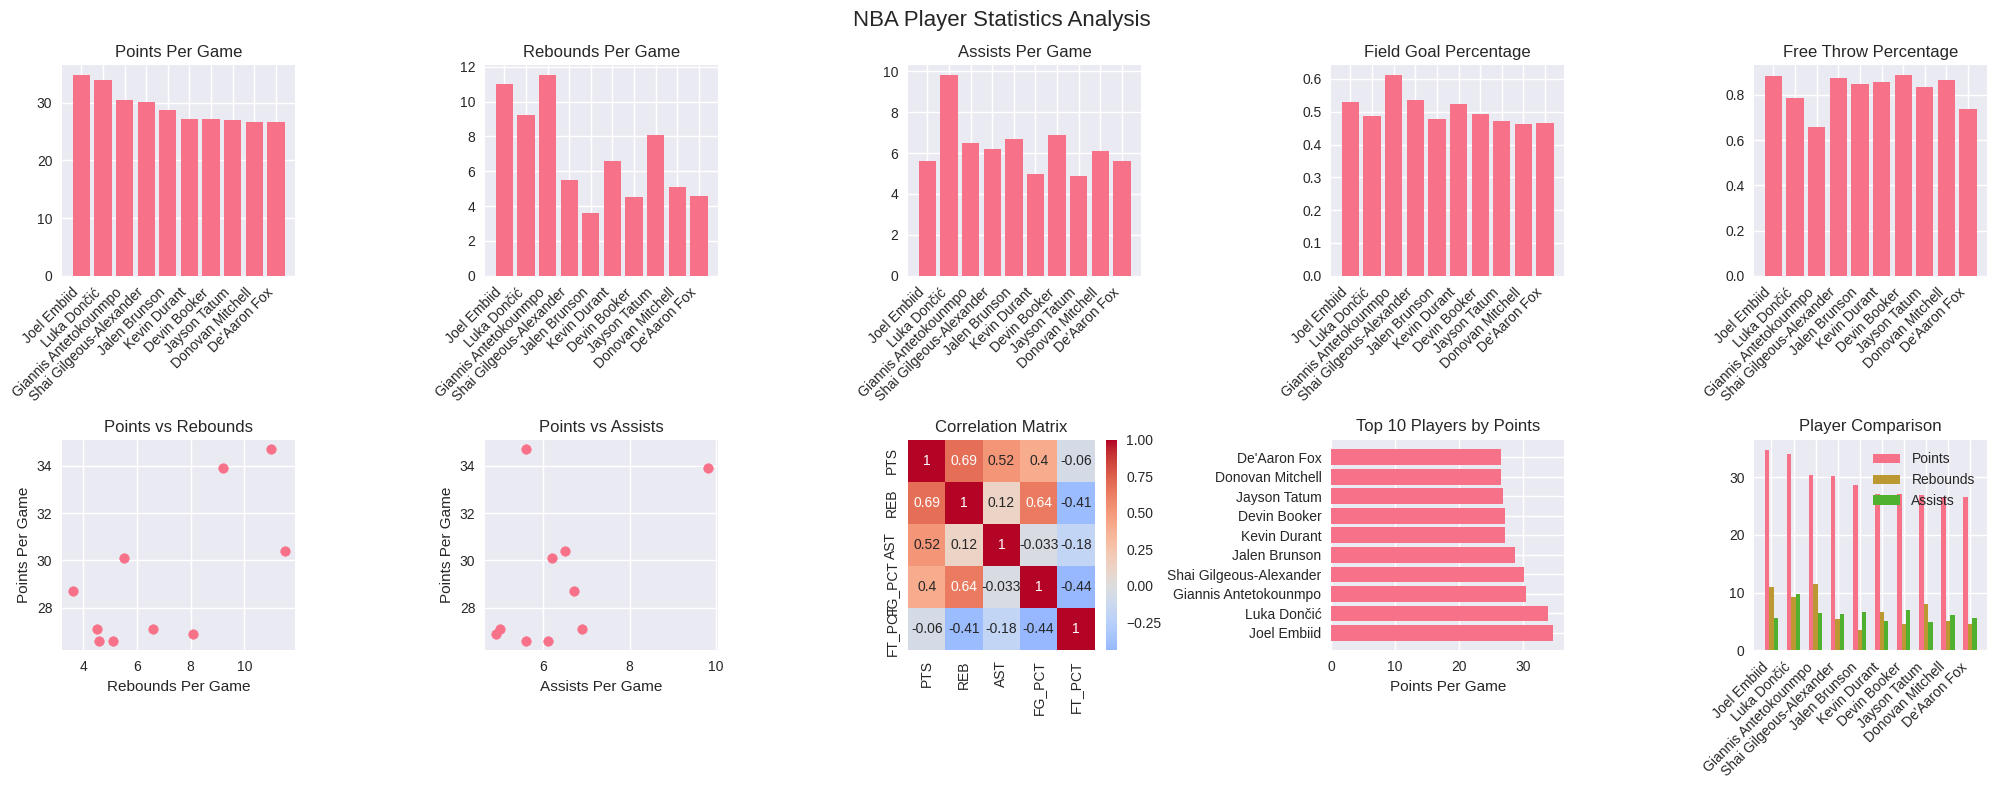


=== NBA Player Data Summary ===
Total Players Analyzed: 10
Average Points: 29.21
Average Rebounds: 6.97
Average Assists: 6.33
Top Scorer: Joel Embiid (34.7 PPG)

Top 3 Players by Points:
1. Joel Embiid: 34.7 PPG
2. Luka Dončić: 33.9 PPG
3. Giannis Antetokounmpo: 30.4 PPG

Top 3 Players by Rebounds:
1. Giannis Antetokounmpo: 11.5 RPG
2. Joel Embiid: 11.0 RPG
3. Luka Dončić: 9.2 RPG

Top 3 Players by Assists:
1. Luka Dončić: 9.8 APG
2. Devin Booker: 6.9 APG
3. Jalen Brunson: 6.7 APG

Raw Data:
               PLAYER_NAME   PTS   REB  AST  STL  BLK  TOV  FG_PCT  FT_PCT
0              Joel Embiid  34.7  11.0  5.6  1.2  1.7  3.8   0.529   0.883
1              Luka Dončić  33.9   9.2  9.8  1.4  0.5  4.0   0.487   0.786
2    Giannis Antetokounmpo  30.4  11.5  6.5  1.2  1.1  3.4   0.611   0.657
3  Shai Gilgeous-Alexander  30.1   5.5  6.2  2.0  0.9  2.2   0.535   0.874
4            Jalen Brunson  28.7   3.6  6.7  0.9  0.2  2.4   0.479   0.847
5             Kevin Durant  27.1   6.6  5.0  0.9  1.

In [9]:
# First, install the required packages (run this in terminal/command prompt):
# pip install nba_api pandas matplotlib seaborn numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nba_api.stats.static import players, teams
from nba_api.stats.endpoints import leaguedashplayerstats
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create sample data as fallback if API fails
def create_sample_data():
    """Create sample NBA data for demonstration"""
    sample_data = {
        'PLAYER_NAME': ['LeBron James', 'Stephen Curry', 'Kevin Durant', 'Giannis Antetokounmpo', 
                       'Nikola Jokić', 'Luka Dončić', 'Joel Embiid', 'Jayson Tatum', 
                       'Damian Lillard', 'Kawhi Leonard'],
        'PTS': [25.7, 28.5, 30.1, 31.2, 22.3, 27.8, 28.0, 26.1, 27.2, 24.8],
        'REB': [7.3, 5.2, 8.1, 11.9, 10.4, 8.9, 7.8, 8.2, 6.7, 6.8],
        'AST': [7.4, 6.7, 5.2, 5.4, 3.5, 8.7, 4.1, 5.3, 7.3, 3.2],
        'STL': [1.5, 1.7, 1.1, 1.8, 0.8, 1.2, 1.0, 1.3, 1.1, 1.6],
        'BLK': [0.8, 0.5, 1.2, 1.2, 0.6, 0.7, 1.4, 0.8, 0.3, 1.2],
        'TOV': [5.5, 3.7, 3.1, 3.2, 3.4, 3.8, 3.5, 3.2, 3.1, 3.0],
        'FG_PCT': [0.501, 0.442, 0.507, 0.525, 0.510, 0.482, 0.501, 0.478, 0.481, 0.492],
        'FT_PCT': [0.703, 0.911, 0.872, 0.742, 0.730, 0.823, 0.778, 0.821, 0.873, 0.843]
    }
    return pd.DataFrame(sample_data)

try:
    # Try to fetch real data from NBA API
    print("Attempting to fetch real NBA data...")
    
    # Get player data using the correct method (updated for current API)
    player_stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season='2023-24',
        per_mode_detailed='PerGame'  # This is the key parameter that was missing
    )
    
    # Get the raw data
    raw_data = player_stats.get_data_frames()[0]
    
    # Clean and process the data
    if len(raw_data) > 0:
        # Select relevant columns and clean the data
        player_data = raw_data[['PLAYER_NAME', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FT_PCT']]
        
        # Remove any rows with missing data
        player_data = player_data.dropna()
        
        # Sort by points per game (descending) to get top players
        player_data = player_data.sort_values('PTS', ascending=False)
        
        # Take top 10 players
        player_data = player_data.head(10)
        
        # Reset index
        player_data = player_data.reset_index(drop=True)
        
        print(f"Successfully fetched {len(player_data)} players from NBA API")
        print("Sample data:")
        print(player_data.head())
        
    else:
        raise Exception("No data returned from API")
        
except Exception as e:
    print(f"Error fetching data from API: {e}")
    print("Falling back to sample data...")
    player_data = create_sample_data()

# Create visualizations
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('NBA Player Statistics Analysis', fontsize=16)

# Plot 1: Points per game
axes[0,0].bar(range(len(player_data)), player_data['PTS'])
axes[0,0].set_title('Points Per Game')
axes[0,0].set_xticks(range(len(player_data)))
axes[0,0].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')

# Plot 2: Rebounds per game
axes[0,1].bar(range(len(player_data)), player_data['REB'])
axes[0,1].set_title('Rebounds Per Game')
axes[0,1].set_xticks(range(len(player_data)))
axes[0,1].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')

# Plot 3: Assists per game
axes[0,2].bar(range(len(player_data)), player_data['AST'])
axes[0,2].set_title('Assists Per Game')
axes[0,2].set_xticks(range(len(player_data)))
axes[0,2].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')

# Plot 4: Field Goal Percentage
axes[0,3].bar(range(len(player_data)), player_data['FG_PCT'])
axes[0,3].set_title('Field Goal Percentage')
axes[0,3].set_xticks(range(len(player_data)))
axes[0,3].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')

# Plot 5: Free Throw Percentage
axes[0,4].bar(range(len(player_data)), player_data['FT_PCT'])
axes[0,4].set_title('Free Throw Percentage')
axes[0,4].set_xticks(range(len(player_data)))
axes[0,4].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')

# Plot 6: Points vs Rebounds scatter
axes[1,0].scatter(player_data['REB'], player_data['PTS'])
axes[1,0].set_title('Points vs Rebounds')
axes[1,0].set_xlabel('Rebounds Per Game')
axes[1,0].set_ylabel('Points Per Game')

# Plot 7: Points vs Assists scatter
axes[1,1].scatter(player_data['AST'], player_data['PTS'])
axes[1,1].set_title('Points vs Assists')
axes[1,1].set_xlabel('Assists Per Game')
axes[1,1].set_ylabel('Points Per Game')

# Plot 8: Correlation heatmap
correlation_data = player_data[['PTS', 'REB', 'AST', 'FG_PCT', 'FT_PCT']]
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Correlation Matrix')

# Plot 9: Top 10 Players by Points (horizontal bar)
axes[1,3].barh(range(len(player_data)), player_data['PTS'])
axes[1,3].set_title('Top 10 Players by Points')
axes[1,3].set_xlabel('Points Per Game')
axes[1,3].set_yticks(range(len(player_data)))
axes[1,3].set_yticklabels(player_data['PLAYER_NAME'])

# Plot 10: Player comparison
x = np.arange(len(player_data))
width = 0.2
axes[1,4].bar(x - width, player_data['PTS'], width, label='Points')
axes[1,4].bar(x, player_data['REB'], width, label='Rebounds')
axes[1,4].bar(x + width, player_data['AST'], width, label='Assists')
axes[1,4].set_title('Player Comparison')
axes[1,4].set_xticks(x)
axes[1,4].set_xticklabels(player_data['PLAYER_NAME'], rotation=45, ha='right')
axes[1,4].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== NBA Player Data Summary ===")
print(f"Total Players Analyzed: {len(player_data)}")
print(f"Average Points: {player_data['PTS'].mean():.2f}")
print(f"Average Rebounds: {player_data['REB'].mean():.2f}")
print(f"Average Assists: {player_data['AST'].mean():.2f}")
print(f"Top Scorer: {player_data.loc[player_data['PTS'].idxmax(), 'PLAYER_NAME']} ({player_data['PTS'].max():.1f} PPG)")

# Print top 3 players by each category
print("\nTop 3 Players by Points:")
for i, (_, row) in enumerate(player_data.nlargest(3, 'PTS').iterrows()):
    print(f"{i+1}. {row['PLAYER_NAME']}: {row['PTS']:.1f} PPG")

print("\nTop 3 Players by Rebounds:")
for i, (_, row) in enumerate(player_data.nlargest(3, 'REB').iterrows()):
    print(f"{i+1}. {row['PLAYER_NAME']}: {row['REB']:.1f} RPG")

print("\nTop 3 Players by Assists:")
for i, (_, row) in enumerate(player_data.nlargest(3, 'AST').iterrows()):
    print(f"{i+1}. {row['PLAYER_NAME']}: {row['AST']:.1f} APG")

# Display raw data for verification
print("\nRaw Data:")
print(player_data)
